# 딥러닝 기초 2일차 실습과제: MLP와 옵티마이저

## 과제 개요
이 과제에서는 실제 의료 데이터를 활용하여 **다층 퍼셉트론(MLP)**을 구현하고, 다양한 **옵티마이저**의 성능을 비교합니다.

### 사용 데이터셋
- **Pima Indians Diabetes Database**
- 768명의 환자 데이터, 8개의 의료 특성
- 목표: 당뇨병 여부 예측 (이진 분류)

### 학습 목표
1. PyTorch로 MLP 모델 구현
2. 순전파와 손실함수 이해
3. 다양한 옵티마이저(SGD, Adam) 비교
4. 학습 곡선 분석

### 예상 소요 시간
약 **1시간**

---

## Part 0: 환경 설정

In [1]:
# 필요한 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 재현성을 위한 시드 설정
torch.manual_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


s## Part 1: 데이터 준비

In [2]:
# ============================================
# 데이터 로드
# diabetes.csv 파일을 노트북과 같은 폴더에 업로드하세요
# ============================================

df = pd.read_csv('diabetes.csv')

print(f"데이터셋 크기: {df.shape}")
print(f"\n특성 목록: {list(df.columns)}")
print(f"\n타겟 분포:")
print(df['Outcome'].value_counts())

df.head()

데이터셋 크기: (768, 9)

특성 목록: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

타겟 분포:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 데이터 전처리
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# Train/Test 분할 (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PyTorch Tensor로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoader 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Input features: {X_train.shape[1]}")

Train: 614 samples
Test: 154 samples
Input features: 8


---

## Part 2: MLP 모델 구현

PyTorch로 다층 퍼셉트론을 구현합니다.

In [4]:
# ============================================
# MLP 모델 정의
# ============================================

class MLP(nn.Module):
    """
    다층 퍼셉트론 모델

    구조: 입력(8) -> 은닉1(64) -> 은닉2(32) -> 출력(1)
    """
    def __init__(self, input_size=8):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            # 첫 번째 은닉층
            nn.Linear(input_size, 64),
            nn.ReLU(),

            # 두 번째 은닉층
            nn.Linear(64, 32),
            nn.ReLU(),

            # 출력층 (이진 분류)
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# 모델 생성 및 구조 확인
model = MLP(input_size=8)
print(model)

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"\n총 파라미터 수: {total_params:,}")

MLP(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

총 파라미터 수: 2,689


### [필수] 과제 2-1: MLP 구조 이해

위 모델의 파라미터 수를 직접 계산해보세요:

1. 첫 번째 층 (8 -> 64): 가중치 = 512, 편향 = 64, 합계 = 576
   - 답변: 576

2. 두 번째 층 (64 -> 32): 합계 = 2080
   - 답변: 2080

3. 출력층 (32 -> 1): 합계 = 33
   - 답변:33

4. 전체 합계가 위에서 출력된 값과 일치하나요?
   - 답변: 네

---

## Part 3: 학습 함수 구현

In [5]:
# ============================================
# 학습 및 평가 함수
# ============================================

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=50):
    """
    모델 학습 함수

    Returns:
        history: 학습 과정 기록 (loss, accuracy)
    """
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        # ===== 학습 단계 =====
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            # 1. 기울기 초기화
            optimizer.zero_grad()

            # 2. 순전파
            outputs = model(X_batch)

            # 3. 손실 계산
            loss = criterion(outputs, y_batch)

            # 4. 역전파
            loss.backward()

            # 5. 가중치 업데이트
            optimizer.step()

            # 통계
            train_loss += loss.item()
            predicted = (outputs > 0.5).float()
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        # ===== 평가 단계 =====
        model.eval() # -> 왜하지? 내일 dropout 배울 때 설명
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                test_loss += loss.item()
                predicted = (outputs > 0.5).float()
                test_correct += (predicted == y_batch).sum().item()
                test_total += y_batch.size(0)

        # 기록
        history['train_loss'].append(train_loss / len(train_loader))
        history['test_loss'].append(test_loss / len(test_loader))
        history['train_acc'].append(train_correct / train_total)
        history['test_acc'].append(test_correct / test_total)

        # 10 에폭마다 출력
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, "
                  f"Test Acc: {history['test_acc'][-1]:.4f}")

    return history


def plot_history(history, title="Training History"):
    """학습 곡선 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(history['train_loss'], label='Train', color='#8FBC8F')
    axes[0].plot(history['test_loss'], label='Test', color='#87CEEB')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', color='#8FBC8F')
    axes[1].plot(history['test_acc'], label='Test', color='#87CEEB')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

기본 MLP 학습 (Adam, lr=0.001)
Epoch [10/50] Train Loss: 0.4461, Test Acc: 0.7078
Epoch [20/50] Train Loss: 0.4349, Test Acc: 0.7273
Epoch [30/50] Train Loss: 0.3993, Test Acc: 0.7143
Epoch [40/50] Train Loss: 0.3723, Test Acc: 0.7208
Epoch [50/50] Train Loss: 0.3581, Test Acc: 0.7273


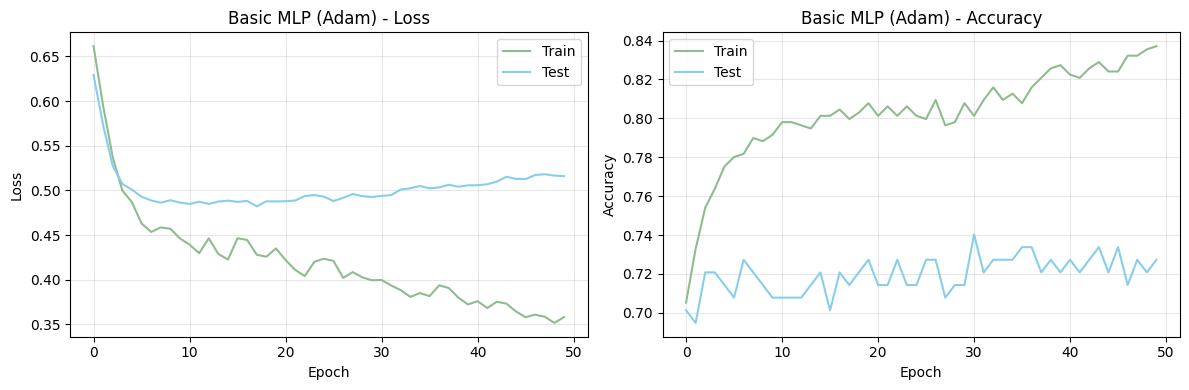

In [6]:
# 기본 모델 학습 (Adam 옵티마이저)
print("=" * 50)
print("기본 MLP 학습 (Adam, lr=0.001)")
print("=" * 50)

model = MLP(input_size=8)
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=50)

plot_history(history, "Basic MLP (Adam)")

---

## Part 4: 옵티마이저 비교 실험

In [7]:
# ============================================
# 옵티마이저 비교 실험
# ============================================

optimizer_configs = {
    'SGD': lambda params: optim.SGD(params, lr=0.01),
    'SGD+Momentum': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'Adam': lambda params: optim.Adam(params, lr=0.001),
}

results = {}

for opt_name, opt_fn in optimizer_configs.items():
    print(f"\n{'='*40}")
    print(f"Training with {opt_name}")
    print("="*40)

    # 새 모델 생성 (공정한 비교를 위해)
    model = MLP(input_size=8)
    criterion = nn.BCELoss()
    optimizer = opt_fn(model.parameters())

    history = train_model(model, train_loader, test_loader,
                          criterion, optimizer, num_epochs=50)

    results[opt_name] = {
        'history': history,
        'final_acc': history['test_acc'][-1]
    }

    print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")


Training with SGD
Epoch [10/50] Train Loss: 0.5930, Test Acc: 0.6753
Epoch [20/50] Train Loss: 0.5339, Test Acc: 0.7013
Epoch [30/50] Train Loss: 0.5077, Test Acc: 0.7273
Epoch [40/50] Train Loss: 0.4896, Test Acc: 0.7338
Epoch [50/50] Train Loss: 0.4685, Test Acc: 0.7208
Final Test Accuracy: 0.7208

Training with SGD+Momentum
Epoch [10/50] Train Loss: 0.4327, Test Acc: 0.7403
Epoch [20/50] Train Loss: 0.4141, Test Acc: 0.7273
Epoch [30/50] Train Loss: 0.4004, Test Acc: 0.7273
Epoch [40/50] Train Loss: 0.3817, Test Acc: 0.7013
Epoch [50/50] Train Loss: 0.3655, Test Acc: 0.7208
Final Test Accuracy: 0.7208

Training with Adam
Epoch [10/50] Train Loss: 0.4368, Test Acc: 0.7273
Epoch [20/50] Train Loss: 0.4111, Test Acc: 0.7273
Epoch [30/50] Train Loss: 0.3907, Test Acc: 0.7208
Epoch [40/50] Train Loss: 0.3863, Test Acc: 0.7143
Epoch [50/50] Train Loss: 0.3563, Test Acc: 0.7338
Final Test Accuracy: 0.7338


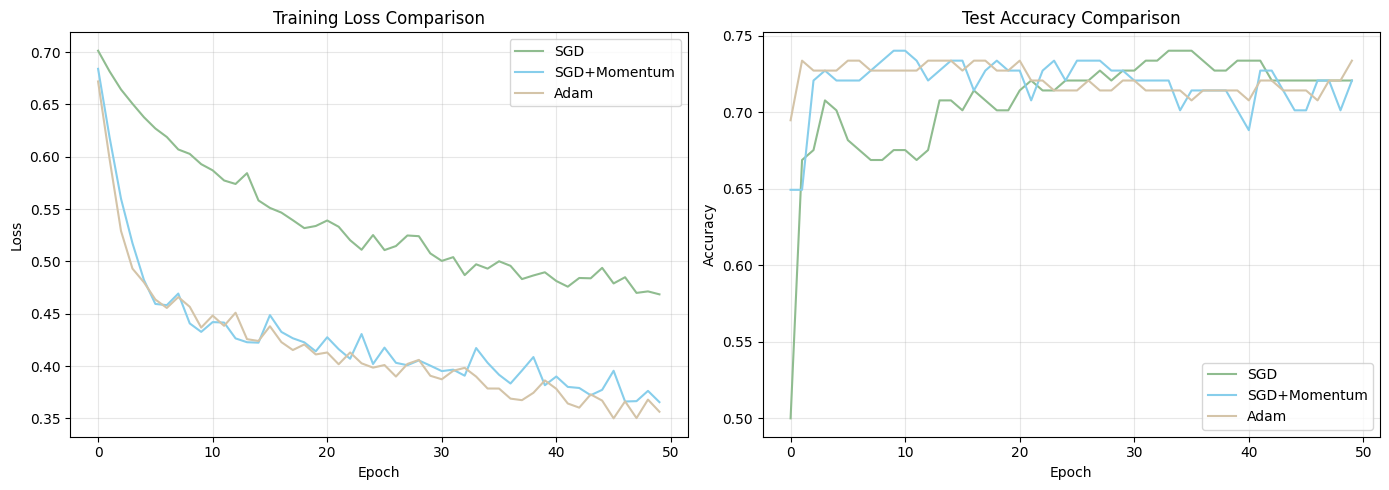


옵티마이저 성능 비교
SGD             | Test Acc: 0.7208
SGD+Momentum    | Test Acc: 0.7208
Adam            | Test Acc: 0.7338


In [8]:
# 옵티마이저 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#8FBC8F', '#87CEEB', '#D4C4A8']

# Train Loss 비교
for i, (name, result) in enumerate(results.items()):
    axes[0].plot(result['history']['train_loss'], label=name, color=colors[i])
axes[0].set_title('Training Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test Accuracy 비교
for i, (name, result) in enumerate(results.items()):
    axes[1].plot(result['history']['test_acc'], label=name, color=colors[i])
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 결과 요약
print("\n" + "=" * 40)
print("옵티마이저 성능 비교")
print("=" * 40)
for name, result in results.items():
    print(f"{name:15} | Test Acc: {result['final_acc']:.4f}")

### [필수] 과제 4-1: 옵티마이저 비교 분석

위 실험 결과를 보고 답하세요:

1. SGD와 Adam 중 어떤 옵티마이저가 더 빠르게 수렴하나요?
   - 답변: Adam

2. Momentum을 추가하면 어떤 변화가 있나요? (SGD vs SGD+Momentum)
   - 답변: SGD보다 loss가 더 빠르게 감소하고 수렴속도 빨라짐. test accuracy도 더 빠르게 상승

---

## Part 5: [도전] 학습률 실험

학습률(Learning Rate)이 학습에 미치는 영향을 실험해보세요.

학습률 비교 실험 (Adam, 0.1)
Epoch [10/50] Train Loss: 0.4959, Test Acc: 0.6818
Epoch [20/50] Train Loss: 0.4248, Test Acc: 0.7273
Epoch [30/50] Train Loss: 0.6672, Test Acc: 0.7532
Epoch [40/50] Train Loss: 0.4804, Test Acc: 0.6429
Epoch [50/50] Train Loss: 0.4529, Test Acc: 0.6169


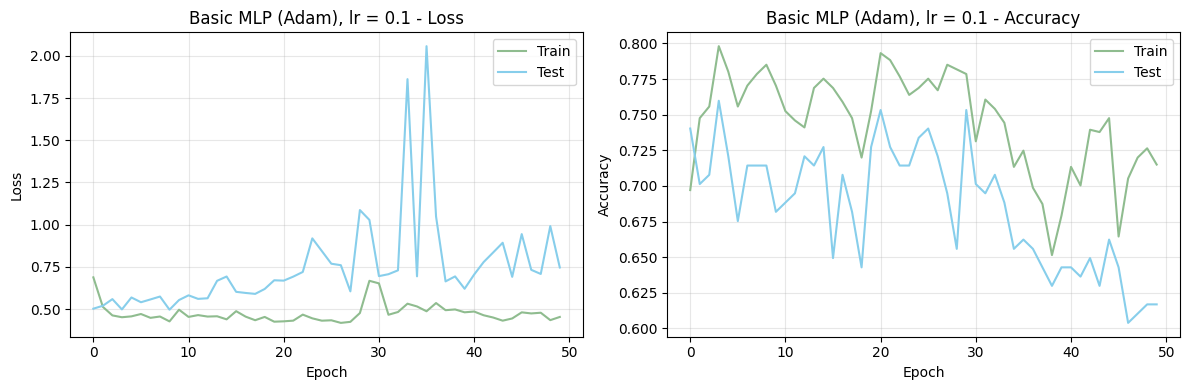

학습률 비교 실험 (Adam, 0.01)
Epoch [10/50] Train Loss: 0.4065, Test Acc: 0.7143
Epoch [20/50] Train Loss: 0.3496, Test Acc: 0.7013
Epoch [30/50] Train Loss: 0.2637, Test Acc: 0.6948
Epoch [40/50] Train Loss: 0.2082, Test Acc: 0.7208
Epoch [50/50] Train Loss: 0.1930, Test Acc: 0.7078


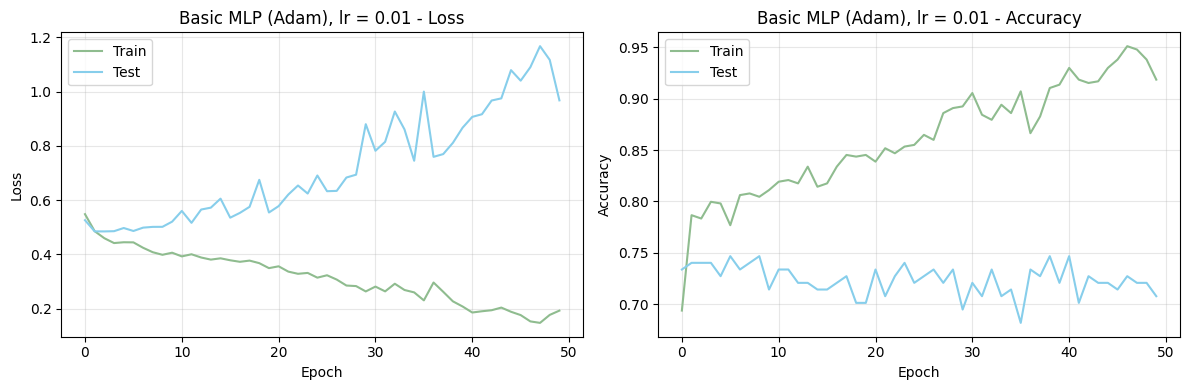

학습률 비교 실험 (Adam, 0.001)
Epoch [10/50] Train Loss: 0.4348, Test Acc: 0.7078
Epoch [20/50] Train Loss: 0.4214, Test Acc: 0.7143
Epoch [30/50] Train Loss: 0.4282, Test Acc: 0.7143
Epoch [40/50] Train Loss: 0.4165, Test Acc: 0.7273
Epoch [50/50] Train Loss: 0.3814, Test Acc: 0.7208


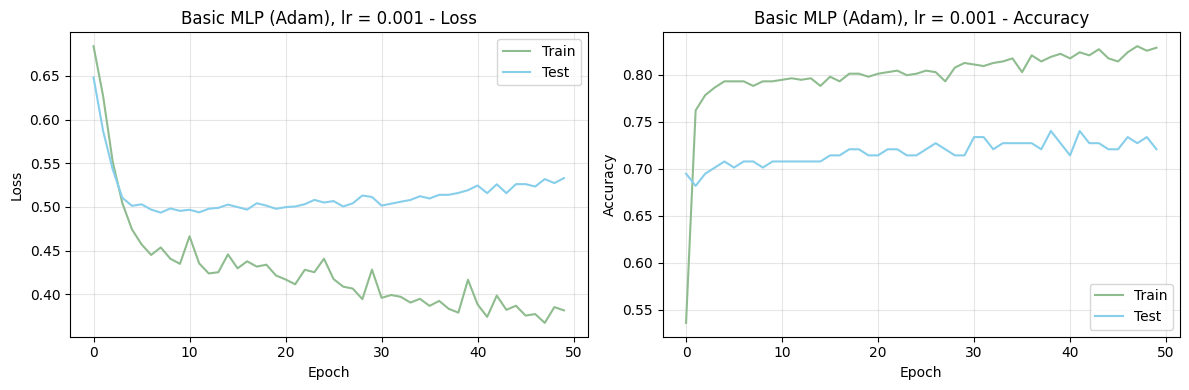

학습률 비교 실험 (Adam, 0.0001)
Epoch [10/50] Train Loss: 0.5965, Test Acc: 0.6688
Epoch [20/50] Train Loss: 0.5344, Test Acc: 0.7338
Epoch [30/50] Train Loss: 0.4883, Test Acc: 0.7597
Epoch [40/50] Train Loss: 0.4690, Test Acc: 0.7532
Epoch [50/50] Train Loss: 0.4706, Test Acc: 0.7532


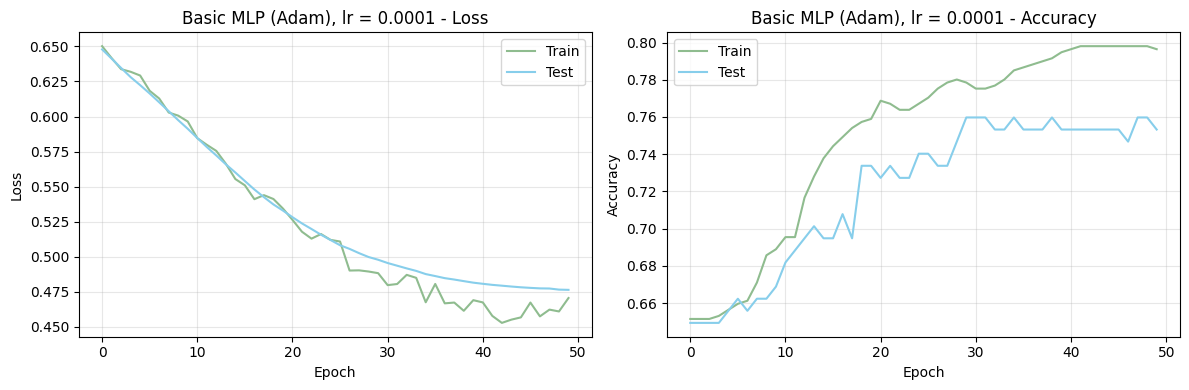

In [9]:
# [도전 과제] 학습률 비교 실험
# TODO: 다양한 학습률(0.1, 0.01, 0.001, 0.0001)로 실험하고 결과를 비교하세요

learning_rates = [0.1, 0.01, 0.001, 0.0001]

# TODO: 각 학습률로 모델을 학습하고 결과를 시각화하세요
# 힌트: 위의 옵티마이저 비교 코드를 참고하세요
# 기본 모델 학습 (Adam 옵티마이저)
results = {}
for lr in learning_rates:
    print("=" * 50)
    print(f"학습률 비교 실험 (Adam, {lr})")
    print("=" * 50)

    model = MLP(input_size=8)
    criterion = nn.BCELoss()  # Binary Cross Entropy
    optimizer = optim.Adam(model.parameters(), lr= lr)

    history = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=50)
    results[f"lr_{lr}"] = {
        'history': history,
        'final_acc': history['test_acc'][-1]
    }
    plot_history(history, f"Basic MLP (Adam), lr = {lr}")

---

## 2일차 학습 정리

오늘 배운 핵심 내용을 체크해보세요:

- [ ] PyTorch로 MLP 모델 구현 (`nn.Module`, `nn.Sequential`)
- [ ] 학습 루프: 순전파 -> 손실 계산 -> 역전파 -> 가중치 업데이트
- [ ] `BCELoss`: 이진 분류용 손실함수
- [ ] SGD vs Adam 옵티마이저의 차이
- [ ] Momentum의 역할

---

## 수고하셨습니다!

### 제출 전 체크리스트
- [ ] 과제 2-1 (MLP 구조 이해) 답변 작성
- [ ] 과제 4-1 (옵티마이저 비교) 답변 작성
- [ ] [선택] 도전 과제 (학습률 실험)